In [70]:
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("sqlite://///Users/rishabh/Desktop/PatrollQ/mlflow.db")

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import silhouette_score

In [72]:
df=pd.read_csv('../data/cleaned_crime_records.csv')

In [11]:
df.columns

Index(['ID', 'Date', 'Primary Type', 'Description', 'Location Description',
       'Arrest', 'Domestic', 'District', 'Ward', 'Community Area', 'Latitude',
       'Longitude', 'hour', 'day', 'month', 'year', 'weekend'],
      dtype='object')

In [73]:
df= df.sample(n=100000, random_state=42)

In [74]:
day_map={
    'Sunday':0,
    'Monday':1,
    'Tuesday':2,
    'Wednesday':3,
    'Thursday':4,
    'Friday':5,
    'Saturday':6,

}

In [75]:
df['day']=df['day'].replace(day_map)

/var/folders/33/6j7x5yjn4vs9rpp5_xx32x740000gn/T/ipykernel_6059/138703465.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['day']=df['day'].replace(day_map)


In [76]:
df['day'].value_counts()

day
5    14874
6    14577
1    14403
0    14241
3    14070
4    13968
2    13867
Name: count, dtype: int64

In [77]:
temp_features = df[['hour', 'day', 'month']]

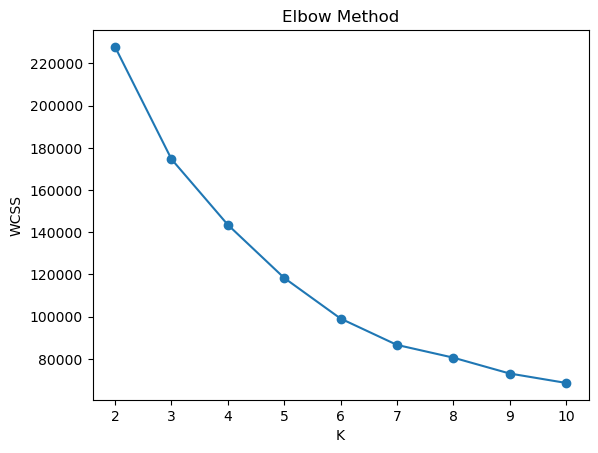

In [78]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = temp_features
X = X.astype('float32')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(temp_features)

In [82]:
from sklearn.cluster import KMeans
mlflow.set_experiment("PatrollQ")

k = 4

with mlflow.start_run(run_name="Kmeans CLustering(Temporal)"):
    kmeans_time = KMeans(n_clusters=k)
    df['time_cluster'] = kmeans_time.fit_predict(temp_features)
    sil_score = silhouette_score(X_scaled, df['time_cluster'])
    print(sil_score)
    mlflow.log_param("algorithm", "KMeans")
    mlflow.log_param("n_clusters", k)
    mlflow.log_metric("silhouette_score", sil_score)
print('done')

0.1373550444841385
done


In [64]:
df['time_cluster'].value_counts().reset_index()

,time_cluster,count
0,1,172010
1,0,110953
2,2,110707
3,3,106330


In [65]:
df[(df['time_cluster']==1)]['hour'].value_counts()

hour
18    26454
19    26060
20    24703
21    22762
22    21703
17    21227
23    19782
16     9319
Name: count, dtype: int64

## From this clear we can say From 4pm to 11pm the crime rate is high 

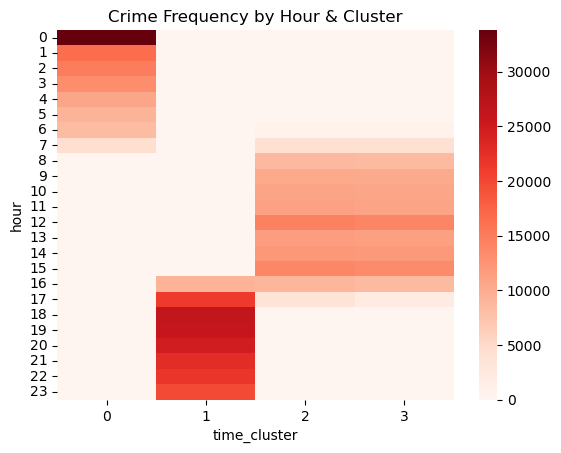

In [66]:
pivot = df.pivot_table(index='hour', columns='time_cluster', aggfunc='size', fill_value=0)

sns.heatmap(pivot, cmap="Reds")
plt.title("Crime Frequency by Hour & Cluster")
plt.show()

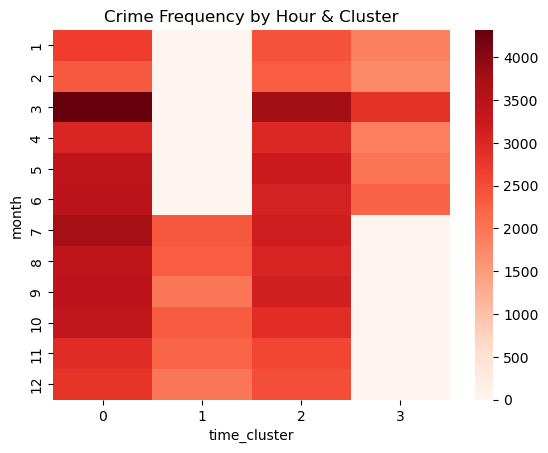

In [84]:
pivot = df.pivot_table(index='month', columns='time_cluster', aggfunc='size', fill_value=0)

sns.heatmap(pivot, cmap="Reds")
plt.title("Crime Frequency by Hour & Cluster")
plt.show()